# Cubit Mesh Evaluation p-Convergence Demo

This docs notebook records the mesh-evaluation demonstration for the Cubit Netgen `.vol` exporter. The Cubit toolbar remains export-only; this p-convergence check is a documentation/validation demo, not an engineering design panel.

The measured data were produced by a clean Cubit batch process that calls APREPRO export commands through `cubit.cmd(...)`, then runs `src/radia/panels/calc_mesh_eval.py` outside the Cubit menu.

In [1]:
from pathlib import Path
import json
import math
from IPython.display import Markdown, display


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / 'validation_test' / 'cubit_mesh_export' / 'p_convergence_demo_results.json').exists():
            return candidate
    return Path.cwd()

repo = find_repo_root()
results_path = repo / 'validation_test' / 'cubit_mesh_export' / 'p_convergence_demo_results.json'
data = json.loads(results_path.read_text(encoding='utf-8'))
result = data['result']
orders = result['orders']
format_qa = result['format_qa']

print('validation_evidence:', results_path.relative_to(repo))
print('generated_at_utc:', data['generated_at_utc'])
print('cubit_version:', data['cubit_version'])
print('python_version:', data['python_version'])
print('orders:', [row['order'] for row in orders])
assert data['demo_kind'] == 'mesh_evaluation_p_convergence'
assert result['max_order'] == 5
assert [row['order'] for row in orders] == [1, 2, 3, 4, 5]


validation_evidence: validation_test\cubit_mesh_export\p_convergence_demo_results.json
generated_at_utc: 2026-06-28T02:04:49Z
cubit_version: 2025.12
python_version: 3.12.10
orders: [1, 2, 3, 4, 5]


## Cubit Command Route

The demonstration uses explicit `cubit.cmd(...)` calls. `play some.jou` is useful for replaying a production geometry, but this docs example keeps the geometry and export APREPRO commands visible and parameterized.

In [2]:
command_lines = [f"cubit.cmd({cmd!r})" for cmd in data['cubit_commands_template']]
display(Markdown('```python\n' + '\n'.join(command_lines) + '\n```'))
assert any('export netgen' in cmd for cmd in data['cubit_commands_template'])
assert any('export gmsh' in cmd for cmd in data['cubit_commands_template'])
assert not any(cmd.startswith('play ') for cmd in data['cubit_commands_template'])


```python
cubit.cmd('reset')
cubit.cmd('create sphere radius 0.05')
cubit.cmd('volume 1 size 0.025')
cubit.cmd('volume 1 scheme tetmesh')
cubit.cmd('mesh volume 1')
cubit.cmd('block 1 add volume 1')
cubit.cmd('block 1 name "sphere"')
cubit.cmd('export netgen "{base}_p1.vol" order 1 overwrite')
cubit.cmd('export netgen "{base}_p2.vol" order 2 overwrite')
cubit.cmd('export netgen "{base}_p3.vol" order 3 overwrite')
cubit.cmd('export netgen "{base}_p4.vol" order 4 overwrite')
cubit.cmd('export netgen "{base}_p5.vol" order 5 overwrite')
cubit.cmd('export gmsh "{base}_qa_gmsh_o1.msh" overwrite')
cubit.cmd('export gmsh "{base}_qa_gmsh_o2.msh" order 2 overwrite')
cubit.cmd('export gmsh "{base}_qa_gmsh_o3.msh" order 3 overwrite')
cubit.cmd('export jmag_nastran "{base}_qa_nastran_o1.bdf" overwrite')
cubit.cmd('export jmag_nastran "{base}_qa_nastran_o2.bdf" order 2 overwrite')
cubit.cmd('export vtk "{base}_qa_vtk_o1.vtk" overwrite')
cubit.cmd('export vtk "{base}_qa_vtk_o2.vtk" order 2 overwrite')
```

## `.vol` p-Convergence

NGSolve loads each exported `.vol` file and integrates volume/area against the CAD values saved by the exporter companion JSON.

In [3]:
header = '| p | Volume error [%] | Area error [%] | NGSolve time [s] |\n|---:|---:|---:|---:|'
body = []
for row in orders:
    body.append(
        f"| {row['order']} | {row['vol_error_pct']:+.6e} | "
        f"{row['area_error_pct']:+.6e} | {row['time']:.4f} |"
    )
display(Markdown('\n'.join([header] + body)))

vol_abs = [abs(row['vol_error_pct']) for row in orders]
area_abs = [abs(row['area_error_pct']) for row in orders]
print('volume_error_drop_p1_to_p5:', vol_abs[0] / vol_abs[-1])
print('area_error_drop_p1_to_p5:', area_abs[0] / area_abs[-1])
assert vol_abs[1] < vol_abs[0]
assert vol_abs[-1] < 1.0e-3
assert area_abs[1] < area_abs[0]
assert area_abs[-1] < 1.0e-3


| p | Volume error [%] | Area error [%] | NGSolve time [s] |
|---:|---:|---:|---:|
| 1 | -9.748789e+00 | -5.383198e+00 | 0.0108 |
| 2 | -2.027370e-01 | -1.326800e-01 | 0.0116 |
| 3 | +1.820900e-02 | +1.310786e-02 | 0.0124 |
| 4 | +8.960909e-04 | +6.003195e-04 | 0.0128 |
| 5 | -1.912004e-05 | -9.044459e-05 | 0.0131 |

volume_error_drop_p1_to_p5: 509872.8566064191
area_error_drop_p1_to_p5: 59519.284643605555


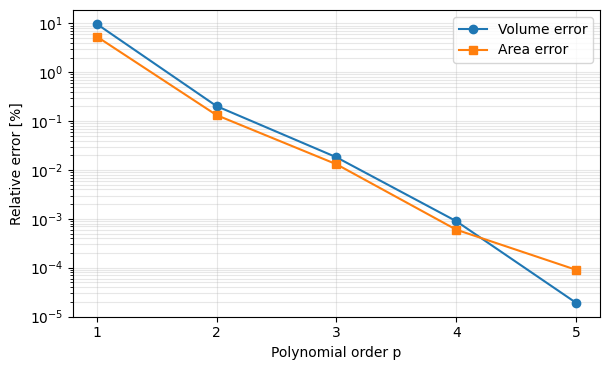

In [4]:
import matplotlib.pyplot as plt

ps = [row['order'] for row in orders]
vol_abs = [abs(row['vol_error_pct']) for row in orders]
area_abs = [abs(row['area_error_pct']) for row in orders]

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.semilogy(ps, vol_abs, marker='o', label='Volume error')
ax.semilogy(ps, area_abs, marker='s', label='Area error')
ax.set_xlabel('Polynomial order p')
ax.set_ylabel('Relative error [%]')
ax.set_xticks(ps)
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## Format QA Snapshot

The same command route also emits GMSH/Nastran/VTK QA files. In this compact docs run the durable check is that no exported curved elements have negative Jacobians and that volume agrees with the `.vol` p-convergence trend. Surface-area integration through GMSH is intentionally not used as the headline metric for this small demo.

In [5]:
rows = []
for row in format_qa:
    rows.append(
        f"| {row['format']} | {row['order']} | {row.get('vol_error_pct', float('nan')):+.6e} | {row.get('neg_det', '')} |"
    )
display(Markdown('| Format | Order | Volume error [%] | negative Jacobians |\n|---|---:|---:|---:|\n' + '\n'.join(rows)))
assert all(row.get('neg_det', 0) == 0 for row in format_qa if 'error' not in row)
assert len(format_qa) == 7


| Format | Order | Volume error [%] | negative Jacobians |
|---|---:|---:|---:|
| gmsh | 1 | -9.748782e+00 | 0 |
| gmsh | 2 | -2.027254e-01 | 0 |
| gmsh | 3 | +1.821833e-02 | 0 |
| nastran | 1 | -9.748789e+00 | 0 |
| nastran | 2 | -2.027379e-01 | 0 |
| vtk | 1 | -9.748782e+00 | 0 |
| vtk | 2 | -2.027254e-01 | 0 |